<a href="https://colab.research.google.com/github/vrundagawade151-crypto/CSL701-CS19-Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Vrunda Vidyadhar Gawade

Roll No : CS19

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Define column names
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
    'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

# Load the dataset
df = pd.read_csv('pima-indians-diabetes.data.csv', names=column_names)

# Print the first five records of the dataset
print("First five records of the dataset:")
display(df.head())

# Print the dataset shape
print(f"\nDataset shape: {df.shape}")

# Print data types of all features
print("\nData types of all features:")
display(df.info())

# Print descriptive statistics of the numeric features
print("\nDescriptive statistics of the numeric features:")
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)

Data types of all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Absolute Count of Outcome:


,count
Outcome,
0,500
1,268



Percentage of Outcome:


,proportion
Outcome,
0,65.104167
1,34.895833


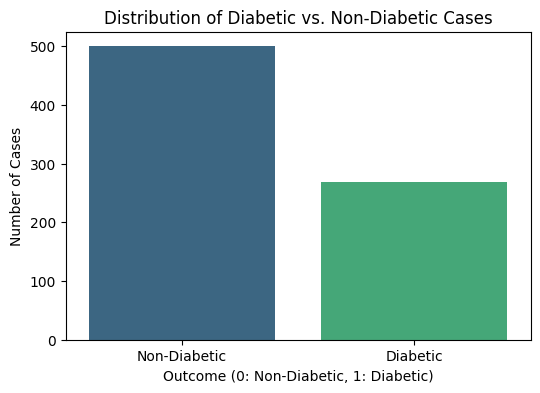

In [21]:
# 1. Calculate and plot class balance
import seaborn as sns
outcome_counts = df['Outcome'].value_counts()
outcome_percentages = df['Outcome'].value_counts(normalize=True) * 100

print("Absolute Count of Outcome:")
display(outcome_counts)
print("\nPercentage of Outcome:")
display(outcome_percentages)

fig_class_balance = plt.figure(figsize=(6, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Diabetic vs. Non-Diabetic Cases')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Number of Cases')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

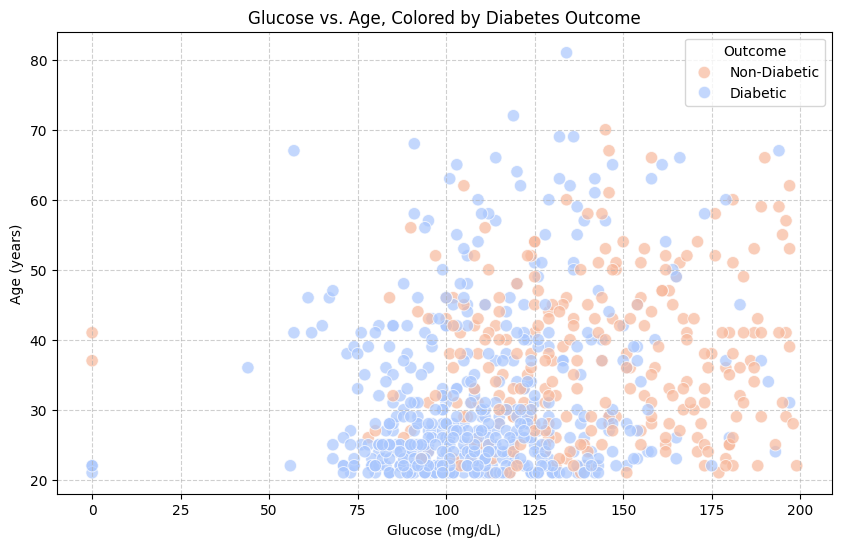

In [22]:
import seaborn as sns
# 2. Create a scatter plot of Age against Glucose, color-coded by Outcome

fig_scatter = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Glucose', y='Age', hue='Outcome', palette='coolwarm', s=80, alpha=0.7)
plt.title('Glucose vs. Age, Colored by Diabetes Outcome')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Age (years)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.show()

### Explanation of linear decision boundary insufficiency:

Based on the scatter plot of 'Glucose' vs. 'Age' color-coded by 'Outcome', it's evident that a simple linear decision boundary (a straight line) would be insufficient to clearly separate the diabetic and non-diabetic classes. The two classes are significantly intertwined and overlap in this 2D feature space. Diabetic and non-diabetic points are not linearly separable; there isn't a clear line that can divide them without a substantial number of misclassifications. This suggests that a more complex, non-linear model or a model considering more features would be necessary to achieve better classification performance.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [23]:
# Identify features where a value of 0 is physically impossible
features_with_impossible_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 values in these features with NaN
for feature in features_with_impossible_zeros:
    df[feature] = df[feature].replace(0, np.nan)

print("Count of NaN values after replacing 0s:")
display(df[features_with_impossible_zeros].isnull().sum())

# Handle missing values by imputing them using the median of the respective feature
for feature in features_with_impossible_zeros:
    median_val = df[feature].median()
    df[feature].fillna(median_val, inplace=True)

print("\nUpdated count of NaN values after median imputation:")
display(df[features_with_impossible_zeros].isnull().sum())

print("\nFirst five records after imputation:")
display(df.head())

print("\nDescriptive statistics after imputation:")
display(df.describe())

Count of NaN values after replacing 0s:


,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11



Updated count of NaN values after median imputation:


/tmp/ipykernel_1155/3767986751.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(median_val, inplace=True)


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



First five records after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Descriptive statistics after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [24]:
# 1. Isolate the feature matrix (X) and the target vector (y)
X = df.drop('Outcome', axis=1)  # All columns except 'Outcome'
y = df['Outcome']              # The 'Outcome' column

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

# 2. Split the dataset into 80% training and 20% test data with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

Shape of feature matrix X: (768, 8)
Shape of target vector y: (768,)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original dataset:
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Class distribution in training set:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in test set:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [25]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) from the given dataset.

    Args:
        X (pd.DataFrame): Feature matrix.
        y (pd.Series): Target vector.

    Returns:
        tuple: A tuple containing:
            - X_star (pd.DataFrame): Bootstrapped feature matrix.
            - y_star (pd.Series): Bootstrapped target vector.
            - oob_indices (np.array): Indices of out-of-bag samples.
    """
    n_samples = X.shape[0]
    # Generate random indices with replacement
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)

    # Get out-of-bag indices
    all_indices = np.arange(n_samples)
    oob_indices = np.setdiff1d(all_indices, np.unique(bootstrap_indices))

    # Create bootstrapped samples
    X_star = X.iloc[bootstrap_indices].reset_index(drop=True)
    y_star = y.iloc[bootstrap_indices].reset_index(drop=True)

    return X_star, y_star, oob_indices

# Verify the function
X_bootstrap, y_bootstrap, oob_indices = get_bootstrap_sample(X_train, y_train)

print("Original training set size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))

print("\nFirst 5 rows of X_train original indices:", X_train.index[:5].tolist())
print("First 5 rows of X_bootstrap indices (showing potential duplicates and reordering):")
# To show duplicates, we can look at the underlying indices that were chosen
# Let's regenerate bootstrap_indices to show the actual selected indices

n_samples_train = X_train.shape[0]
sample_indices = np.random.choice(n_samples_train, n_samples_train, replace=True)

print("Some original indices chosen in bootstrap sample (may contain duplicates):")
display(pd.Series(sample_indices).value_counts().head())

print("\nNumber of unique indices in bootstrap sample:", len(np.unique(sample_indices)))
print("Number of out-of-bag (OOB) samples:", len(oob_indices))

print("\nExample of X_bootstrap head (showing data from resampled indices):")
display(X_bootstrap.head())

Original training set size: 614
Bootstrap sample size: 614

First 5 rows of X_train original indices: [353, 711, 373, 46, 682]
First 5 rows of X_bootstrap indices (showing potential duplicates and reordering):
Some original indices chosen in bootstrap sample (may contain duplicates):


,count
174,5
145,5
457,4
351,4
14,4



Number of unique indices in bootstrap sample: 379
Number of out-of-bag (OOB) samples: 231

Example of X_bootstrap head (showing data from resampled indices):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,3,89.0,74.0,16.0,85.0,30.4,0.551,38
1,4,189.0,110.0,31.0,125.0,28.5,0.680,37
2,7,178.0,84.0,29.0,125.0,39.9,0.331,41
3,1,172.0,68.0,49.0,579.0,42.4,0.702,28
4,2,128.0,64.0,42.0,125.0,40.0,1.101,24


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [26]:
ensemble_models = []
B = 50  # Number of bootstrap iterations

print(f"Training {B} Decision Tree classifiers...")

for i in range(B):
    # Generate a unique bootstrap training dataset
    X_star_b, y_star_b, _ = get_bootstrap_sample(X_train, y_train)

    # Instantiate a Scikit-Learn DecisionTreeClassifier (fully grown)
    model_b = DecisionTreeClassifier(max_depth=None, random_state=42 + i) # Vary random_state for diversity

    # Fit the decision tree on the bootstrapped training subset
    model_b.fit(X_star_b, y_star_b)

    # Append the trained model to the ensemble list
    ensemble_models.append(model_b)

print(f"Ensemble of {len(ensemble_models)} models created successfully.")

Training 50 Decision Tree classifiers...
Ensemble of 50 models created successfully.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [27]:
from collections import Counter

def custom_bagging_predict(ensemble, X_test):
    """
    Generates final predictions for the Bagging ensemble using majority voting.

    Args:
        ensemble (list): A list of trained base classifiers (e.g., DecisionTreeClassifier).
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.array: Final majority-voted predictions for each sample in X_test.
    """
    # Collect predictions from all models in the ensemble
    all_predictions = []
    for model in ensemble:
        all_predictions.append(model.predict(X_test))

    # Convert list of predictions to a NumPy array for easier manipulation
    all_predictions = np.array(all_predictions)

    # For each sample, find the majority vote
    final_predictions = []
    for i in range(X_test.shape[0]):
        # Get predictions for the current sample from all models
        sample_preds = all_predictions[:, i]

        # Count occurrences of each prediction (0 or 1)
        vote_counts = Counter(sample_preds)

        # Determine the majority class. If tie, prefer class 0 as a default (or handle as needed)
        if vote_counts.get(0, 0) >= vote_counts.get(1, 0):
            final_predictions.append(0)
        else:
            final_predictions.append(1)

    return np.array(final_predictions)

# Verify the function (optional, but good practice)
# You can test with a small subset of X_test or directly predict for the full X_test
print("Generating predictions for X_test using custom bagging ensemble...")
y_pred_bagging = custom_bagging_predict(ensemble_models, X_test)
print(f"Shape of Bagging predictions: {y_pred_bagging.shape}")
print(f"First 10 Bagging predictions: {y_pred_bagging[:10]}")

Generating predictions for X_test using custom bagging ensemble...
Shape of Bagging predictions: (154,)
First 10 Bagging predictions: [1 0 0 0 0 0 0 1 0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [28]:
# 1. Train a standalone, single DecisionTreeClassifier on the original training data
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)

# 2. Predict the classes for X_test using both the single tree and custom Bagging classifier
y_pred_single_tree = single_tree_model.predict(X_test)
# y_pred_bagging is already computed from the previous step

print("\n--- Single Decision Tree Performance ---")
# 3. Construct a Confusion Matrix for the single tree
cm_single_tree = confusion_matrix(y_test, y_pred_single_tree)
print("Confusion Matrix (Single Tree):\n", cm_single_tree)

# 4. Compute and print Accuracy, Precision, Recall, and F1-Score for the single tree
accuracy_single_tree = accuracy_score(y_test, y_pred_single_tree)
precision_single_tree = precision_score(y_test, y_pred_single_tree)
recall_single_tree = recall_score(y_test, y_pred_single_tree)
f1_single_tree = f1_score(y_test, y_pred_single_tree)

print(f"Accuracy (Single Tree): {accuracy_single_tree:.4f}")
print(f"Precision (Single Tree): {precision_single_tree:.4f}")
print(f"Recall (Single Tree): {recall_single_tree:.4f}")
print(f"F1-Score (Single Tree): {f1_single_tree:.4f}")

print("\n--- Custom Bagging Ensemble Performance ---")
# 3. Construct a Confusion Matrix for the custom Bagging classifier
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
print("Confusion Matrix (Bagging Ensemble):\n", cm_bagging)

# 4. Compute and print Accuracy, Precision, Recall, and F1-Score for the custom Bagging classifier
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

print(f"Accuracy (Bagging Ensemble): {accuracy_bagging:.4f}")
print(f"Precision (Bagging Ensemble): {precision_bagging:.4f}")
print(f"Recall (Bagging Ensemble): {recall_bagging:.4f}")
print(f"F1-Score (Bagging Ensemble): {f1_bagging:.4f}")



--- Single Decision Tree Performance ---
Confusion Matrix (Single Tree):
 [[79 21]
 [28 26]]
Accuracy (Single Tree): 0.6818
Precision (Single Tree): 0.5532
Recall (Single Tree): 0.4815
F1-Score (Single Tree): 0.5149

--- Custom Bagging Ensemble Performance ---
Confusion Matrix (Bagging Ensemble):
 [[85 15]
 [24 30]]
Accuracy (Bagging Ensemble): 0.7468
Precision (Bagging Ensemble): 0.6667
Recall (Bagging Ensemble): 0.5556
F1-Score (Bagging Ensemble): 0.6061


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.


--- ROC-AUC Analysis ---
AUC (Single Decision Tree): 0.6357
AUC (Custom Bagging Ensemble): 0.8193


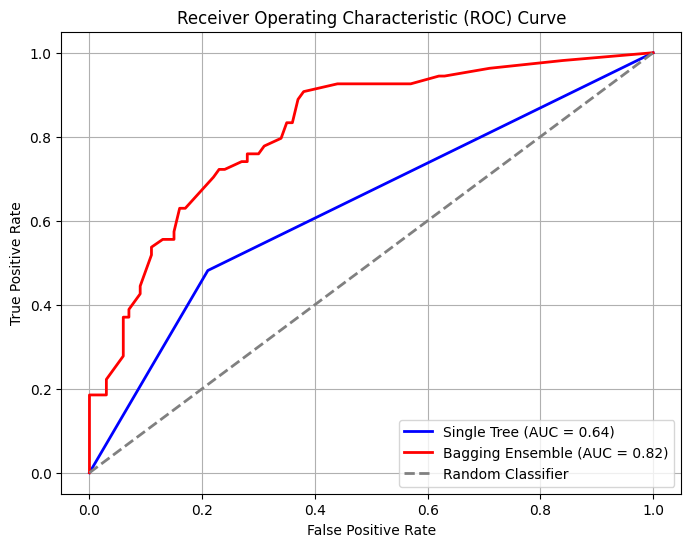

In [29]:
from sklearn.metrics import roc_curve, auc

# 1. Calculate predicted class probabilities for the single decision tree
y_prob_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# 1. Calculate predicted class probabilities for the custom Bagging model
# We need to average the predict_proba from all models in the ensemble
all_prob_predictions = []
for model in ensemble_models:
    all_prob_predictions.append(model.predict_proba(X_test)[:, 1])

y_prob_bagging = np.mean(all_prob_predictions, axis=0)

# Calculate ROC curve and AUC for single tree
fpr_single, tpr_single, _ = roc_curve(y_test, y_prob_single_tree)
auc_single = auc(fpr_single, tpr_single)

# Calculate ROC curve and AUC for custom Bagging
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = auc(fpr_bagging, tpr_bagging)

print("\n--- ROC-AUC Analysis ---")
print(f"AUC (Single Decision Tree): {auc_single:.4f}")
print(f"AUC (Custom Bagging Ensemble): {auc_bagging:.4f}")

# 2. Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_single, tpr_single, color='blue', lw=2, label=f'Single Tree (AUC = {auc_single:.2f})')
plt.plot(fpr_bagging, tpr_bagging, color='red', lw=2, label=f'Bagging Ensemble (AUC = {auc_bagging:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [30]:
from sklearn.ensemble import BaggingClassifier

# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
sk_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=B, # Use the same number of estimators as our custom ensemble
    random_state=42
)

# 2. Fit the classifier on the training set
print("\nTraining Scikit-Learn's BaggingClassifier...")
sk_bagging_model.fit(X_train, y_train)

# 3. Evaluate it on the test set
y_pred_sk_bagging = sk_bagging_model.predict(X_test)

print("\n--- Scikit-Learn BaggingClassifier Performance ---")
# Confusion Matrix
cm_sk_bagging = confusion_matrix(y_test, y_pred_sk_bagging)
print("Confusion Matrix (Scikit-Learn Bagging):\n", cm_sk_bagging)

# Performance metrics
accuracy_sk_bagging = accuracy_score(y_test, y_pred_sk_bagging)
precision_sk_bagging = precision_score(y_test, y_pred_sk_bagging)
recall_sk_bagging = recall_score(y_test, y_pred_sk_bagging)
f1_sk_bagging = f1_score(y_test, y_pred_sk_bagging)

print(f"Accuracy (Scikit-Learn Bagging): {accuracy_sk_bagging:.4f}")
print(f"Precision (Scikit-Learn Bagging): {precision_sk_bagging:.4f}")
print(f"Recall (Scikit-Learn Bagging): {recall_sk_bagging:.4f}")
print(f"F1-Score (Scikit-Learn Bagging): {f1_sk_bagging:.4f}")

print("\n--- Comparison with Custom Bagging Ensemble ---")
print(f"Custom Bagging Accuracy: {accuracy_bagging:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_sk_bagging:.4f}")
print(f"Custom Bagging F1-Score: {f1_bagging:.4f}")
print(f"Scikit-Learn Bagging F1-Score: {f1_sk_bagging:.4f}")


Training Scikit-Learn's BaggingClassifier...

--- Scikit-Learn BaggingClassifier Performance ---
Confusion Matrix (Scikit-Learn Bagging):
 [[85 15]
 [26 28]]
Accuracy (Scikit-Learn Bagging): 0.7338
Precision (Scikit-Learn Bagging): 0.6512
Recall (Scikit-Learn Bagging): 0.5185
F1-Score (Scikit-Learn Bagging): 0.5773

--- Comparison with Custom Bagging Ensemble ---
Custom Bagging Accuracy: 0.7468
Scikit-Learn Bagging Accuracy: 0.7338
Custom Bagging F1-Score: 0.6061
Scikit-Learn Bagging F1-Score: 0.5773


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?